# Cross-City Restaurant Inspection Analysis

**Project:** DataBridge — Data Engineering Spring 2026  
**Tasks:** 2.6 (notebook setup) + 3.5 (RQ1 + RQ2 analysis)

## Research questions answered here

- **RQ1 — Compliance rates.** Do compliance outcomes (Pass / Conditional / Fail) differ significantly across NYC, Chicago, and Boston after restricting to comparable inspection events?
- **RQ2 — Violation patterns.** Which violation taxonomy categories dominate in each city, and which categories are universal vs. city-specific?

RQ3 (re-inspections) lives in `analysis/rq3_reinspections.py`. RQ4 (crosswalk evaluation) lives in `analysis/rq4_crosswalk_eval.py`.

## Methodology guardrails

All cross-city comparisons use the **initial standard inspection** subset:
- `is_reinspection = FALSE` — exclude follow-ups, since re-inspections oversample failing restaurants and skew compliance rates.
- `is_standard_inspection = TRUE` — exclude NYC's non-standard inspection types (Smoke-Free, Trans Fat, Calorie Posting, Sodium Warning, Administrative Miscellaneous) which never receive scores or grades and have no Chicago/Boston counterparts.
- `outcome_tier IS NOT NULL` — drop the small share of NYC rows where neither a grade nor a usable score was available.

Window: 2022-01-01 to 2025-12-31 (set during cleaning, ~98.5% of NYC's rolling-window data falls in this range).


In [3]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DB_PATH = os.path.join('..', 'data', 'integrated', 'databridge.duckdb')
OUT_DIR = os.path.join('..', 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

CITY_ORDER = ['nyc', 'chicago', 'boston']
CITY_COLORS = {'nyc': '#1f77b4', 'chicago': '#ff7f0e', 'boston': '#2ca02c'}
TIER_ORDER = ['Pass', 'Conditional', 'Fail']
TIER_COLORS = {'Pass': '#55a868', 'Conditional': '#dd8452', 'Fail': '#c44e52'}

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

con = duckdb.connect(DB_PATH, read_only=True)
print('Connected to', DB_PATH)

Connected to ..\data\integrated\databridge.duckdb


## Sanity check — table sizes

In [4]:
for table in ['dim_geography', 'dim_restaurants', 'fact_inspections',
              'dim_violations', 'dim_violation_taxonomy',
              'dim_violation_crosswalk']:
    n = con.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    print(f'  {table:30s} {n:>10,}')

  dim_geography                          30
  dim_restaurants                    40,916
  fact_inspections                  148,807
  dim_violations                    544,641
  dim_violation_taxonomy                 64
  dim_violation_crosswalk                90


## RQ1 — Compliance rates across cities

We compute the share of initial standard inspections in each outcome tier (Pass / Conditional / Fail) for each city, with 95 % Wilson-score confidence intervals on each rate. We then run a 3 × 3 chi-square test of independence to test whether outcome differs by city, and follow with a Cramér's V effect size to interpret the magnitude.

In [5]:
rq1 = con.execute("""
    SELECT city, outcome_tier, COUNT(*) AS n
    FROM fact_inspections
    WHERE is_reinspection = FALSE
      AND is_standard_inspection = TRUE
      AND outcome_tier IS NOT NULL
    GROUP BY city, outcome_tier
    ORDER BY city, outcome_tier
""").df()

pivot = rq1.pivot_table(index='city', columns='outcome_tier',
                        values='n', fill_value=0)
pivot = pivot.reindex(index=CITY_ORDER, columns=TIER_ORDER, fill_value=0)
pivot['total'] = pivot.sum(axis=1)

# Percentages
pct = pivot[TIER_ORDER].div(pivot['total'], axis=0) * 100
pct = pct.round(2)

print('Counts:')
print(pivot)
print('\nPercentages:')
print(pct)

Counts:
outcome_tier       Pass  Conditional       Fail      total
city                                                      
nyc          32,021.000   11,707.000 11,252.000 54,980.000
chicago      17,241.000    6,686.000  8,796.000 32,723.000
boston        5,726.000    1,627.000  9,211.000 16,564.000

Percentages:
outcome_tier   Pass  Conditional   Fail
city                                   
nyc          58.240       21.290 20.470
chicago      52.690       20.430 26.880
boston       34.570        9.820 55.610


In [6]:
def wilson_ci(k, n, z=1.96):
    """Wilson score 95% CI for a proportion k/n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n*n))) / denom
    return (centre - half, centre + half)

ci_rows = []
for city in CITY_ORDER:
    total = int(pivot.loc[city, 'total'])
    for tier in TIER_ORDER:
        k = int(pivot.loc[city, tier])
        lo, hi = wilson_ci(k, total)
        ci_rows.append({
            'city': city, 'outcome_tier': tier,
            'n': k, 'total': total,
            'rate': k / total if total else np.nan,
            'ci_low': lo, 'ci_high': hi,
        })
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(os.path.join(OUT_DIR, 'rq1_compliance_rates.csv'), index=False)
ci_df

,city,outcome_tier,n,total,rate,ci_low,ci_high
0,nyc,Pass,32021,54980,0.582,0.578,0.587
1,nyc,Conditional,11707,54980,0.213,0.210,0.216
2,nyc,Fail,11252,54980,0.205,0.201,0.208
3,chicago,Pass,17241,32723,0.527,0.521,0.532
4,chicago,Conditional,6686,32723,0.204,0.200,0.209
5,chicago,Fail,8796,32723,0.269,0.264,0.274
6,boston,Pass,5726,16564,0.346,0.338,0.353
7,boston,Conditional,1627,16564,0.098,0.094,0.103
8,boston,Fail,9211,16564,0.556,0.549,0.564


In [7]:
# Chi-square test of independence (city x outcome_tier)
obs = pivot[TIER_ORDER].values
chi2, p_value, dof, expected = stats.chi2_contingency(obs)

n_total = obs.sum()
min_dim = min(obs.shape) - 1
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f'Chi-square test of independence (city x outcome_tier)')
print(f'  chi2       = {chi2:,.2f}')
print(f'  dof        = {dof}')
print(f'  p-value    = {p_value:.3e}')
print(f'  N          = {n_total:,}')
print(f"  Cramer's V = {cramers_v:.3f}")
print()
if p_value < 0.001:
    print('  -> Reject null: outcome distribution depends on city (p < 0.001).')
elif p_value < 0.05:
    print('  -> Reject null at alpha=0.05.')
else:
    print('  -> Fail to reject null.')

Chi-square test of independence (city x outcome_tier)
  chi2       = 7,888.46
  dof        = 4
  p-value    = 0.000e+00
  N          = 104,267.0
  Cramer's V = 0.194

  -> Reject null: outcome distribution depends on city (p < 0.001).


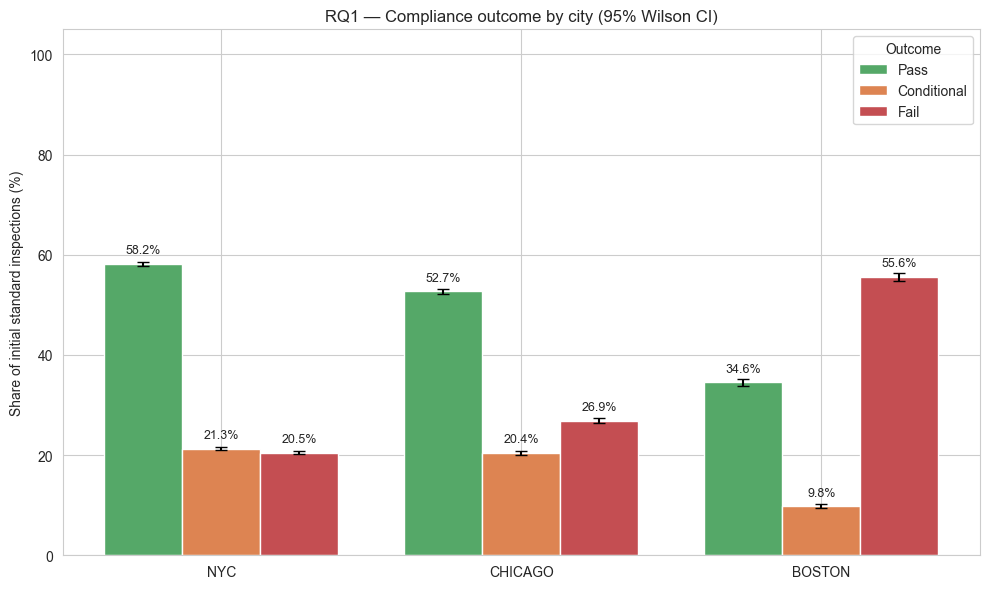

In [8]:
# Grouped bar chart with 95% CIs
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CITY_ORDER))
w = 0.26

for i, tier in enumerate(TIER_ORDER):
    sub = ci_df[ci_df['outcome_tier'] == tier].set_index('city').loc[CITY_ORDER]
    rates_pct = sub['rate'].values * 100
    err_low = (sub['rate'].values - sub['ci_low'].values) * 100
    err_high = (sub['ci_high'].values - sub['rate'].values) * 100
    bars = ax.bar(x + (i - 1) * w, rates_pct, w,
                  label=tier, color=TIER_COLORS[tier],
                  yerr=[err_low, err_high], capsize=4)
    for b, v in zip(bars, rates_pct):
        ax.text(b.get_x() + b.get_width()/2, v + 1.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in CITY_ORDER])
ax.set_ylabel('Share of initial standard inspections (%)')
ax.set_title('RQ1 — Compliance outcome by city (95% Wilson CI)')
ax.legend(title='Outcome', loc='upper right')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'rq1_compliance_rates.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### RQ1 — pairwise post-hoc tests

Pairwise 2 × 3 chi-squares with Bonferroni correction over the three city pairs. We report each pair's chi-square statistic, raw p, Bonferroni-corrected p, and Cramér's V.

In [9]:
from itertools import combinations
pairs = list(combinations(CITY_ORDER, 2))
rows = []
for a, b in pairs:
    sub = pivot.loc[[a, b], TIER_ORDER].values
    chi, p, dof_, _ = stats.chi2_contingency(sub)
    n_pair = sub.sum()
    v = np.sqrt(chi / (n_pair * (min(sub.shape) - 1)))
    rows.append({
        'pair': f'{a} vs {b}',
        'chi2': chi,
        'dof': dof_,
        'p_value': p,
        'p_value_bonferroni': min(1.0, p * len(pairs)),
        'cramers_v': v,
    })
posthoc = pd.DataFrame(rows)
posthoc.to_csv(os.path.join(OUT_DIR, 'rq1_posthoc_pairs.csv'), index=False)
posthoc

,pair,chi2,dof,p_value,p_value_bonferroni,cramers_v
0,nyc vs chicago,489.137,2,0.000,0.000,0.075
1,nyc vs boston,"7,746.989",2,0.000,0.000,0.329
2,chicago vs boston,"3,992.976",2,0.000,0.000,0.285


## RQ2 — Violation patterns across cities

Three views.

1. **Top 10 raw violation descriptions per city.** What dominates each city's inspection record before any cross-city normalization?
2. **Top 10 unified taxonomy categories per city.** Using Rithujaa's HDBSCAN+LLM taxonomy, what does each city's violation profile look like in a shared vocabulary?
3. **Heatmap of taxonomy share per city.** A normalized view that highlights which categories are universal vs. city-specific.

In [10]:
# Top 10 raw violation descriptions per city (filtered to comparable inspections)
raw_top = con.execute("""
    SELECT v.city, v.violation_description, COUNT(*) AS n
    FROM dim_violations v
    JOIN fact_inspections fi ON v.inspection_id = fi.inspection_id
    WHERE fi.is_reinspection = FALSE
      AND fi.is_standard_inspection = TRUE
      AND v.violation_description IS NOT NULL
    GROUP BY v.city, v.violation_description
""").df()

for city in CITY_ORDER:
    sub = raw_top[raw_top['city'] == city].nlargest(10, 'n').reset_index(drop=True)
    sub['violation_description'] = sub['violation_description'].str.slice(0, 80)
    print(f'\n--- {city.upper()} top 10 raw violations ---')
    print(sub.to_string(index=False))


--- NYC top 10 raw violations ---
city                                                            violation_description     n
 nyc Non-food contact surface or equipment made of unacceptable material, not kept cl 26408
 nyc Establishment is not free of harborage or conditions conducive to rodents, insec 16533
 nyc Food contact surface not properly washed, rinsed and sanitized after each use an 12993
 nyc Anti-siphonage or back-flow prevention device not provided where required; equip 11960
 nyc Cold TCS food item held above 41 °F; smoked or processed fish held above 38 °F;  11851
 nyc Food, supplies, or equipment not protected from potential source of contaminatio 10014
 nyc                                   Hot TCS food item not held at or above 140 °F.  9653
 nyc         Evidence of mice or live mice in establishment's food or non-food areas.  9174
 nyc Filth flies or food/refuse/sewage associated with (FRSA) flies or other nuisance  6140
 nyc Food Protection Certificate (FPC) not he

In [11]:
# Top 10 unified taxonomy categories per city
tax_top_q = """
    SELECT v.city,
           t.category_name,
           COUNT(*) AS n
    FROM dim_violations v
    JOIN fact_inspections fi ON v.inspection_id = fi.inspection_id
    JOIN dim_violation_taxonomy t
      ON v.taxonomy_category_id = t.taxonomy_category_id
    WHERE fi.is_reinspection = FALSE
      AND fi.is_standard_inspection = TRUE
    GROUP BY v.city, t.category_name
"""
tax_top = con.execute(tax_top_q).df()

for city in CITY_ORDER:
    sub = tax_top[tax_top['city'] == city].nlargest(10, 'n').reset_index(drop=True)
    print(f'\n--- {city.upper()} top 10 taxonomy categories ---')
    print(sub.to_string(index=False))
tax_top.to_csv(os.path.join(OUT_DIR, 'rq2_top_categories_by_city.csv'), index=False)


--- NYC top 10 taxonomy categories ---
city                           category_name     n
 nyc     Surface Cleanliness and Maintenance 44226
 nyc                 Pest Infestation Issues 38112
 nyc        Holding and Cooking Temperatures 26059
 nyc                Contamination Prevention 13270
 nyc              Plumbing and Sewage Issues 12610
 nyc               Food Safety Certification  5322
 nyc Warewashing and Sanitization Compliance  4382
 nyc             Food Safety and Preparation  4234
 nyc    Sanitation and Facilities Compliance  4047
 nyc      Contamination and Chemical Hazards  3586

--- CHICAGO top 10 taxonomy categories ---
   city                        category_name     n
chicago Sanitation and Facilities Compliance 27455
chicago  Surface Cleanliness and Maintenance 26924
chicago            Food Safety Certification  8976
chicago          Handwashing Sink Compliance  8588
chicago       Backflow Prevention Compliance  7488
chicago  Ventilation and Lighting Compliance  714

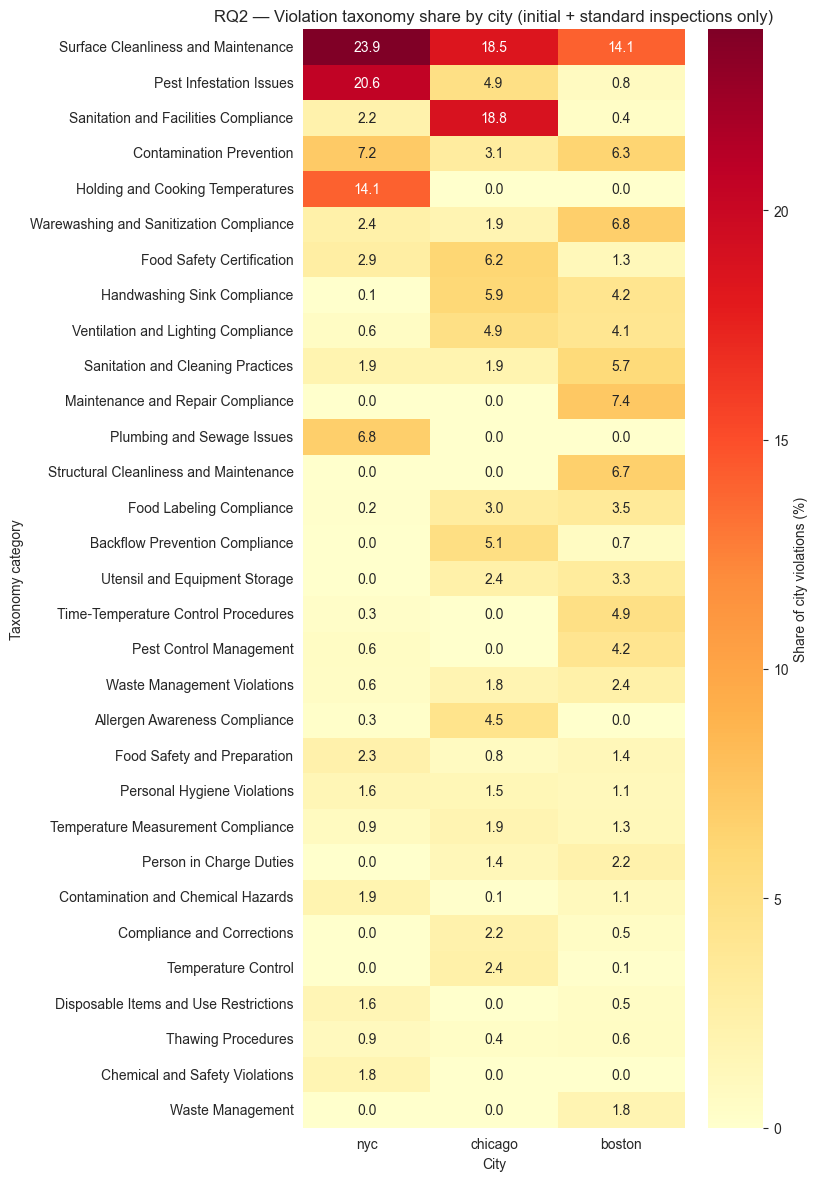

In [12]:
# Heatmap: normalized share of taxonomy categories per city.
# Show only categories that appear in at least one city's top 15 to keep the
# figure readable.
share = tax_top.pivot_table(index='category_name', columns='city',
                            values='n', fill_value=0)
share = share.reindex(columns=CITY_ORDER, fill_value=0)
share_pct = share.div(share.sum(axis=0), axis=1) * 100  # column-normalized

top_per_city = set()
for city in CITY_ORDER:
    top_per_city.update(share_pct[city].sort_values(ascending=False).head(15).index)
share_top = share_pct.loc[sorted(top_per_city)].copy()

# Sort by total share (rough overall importance)
share_top = share_top.assign(_tot=share_top.sum(axis=1)).sort_values(
    '_tot', ascending=False).drop(columns='_tot')

fig, ax = plt.subplots(figsize=(8, 0.32 * len(share_top) + 2))
sns.heatmap(share_top, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Share of city violations (%)'}, ax=ax)
ax.set_title('RQ2 — Violation taxonomy share by city '
             '(initial + standard inspections only)')
ax.set_ylabel('Taxonomy category')
ax.set_xlabel('City')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'rq2_taxonomy_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Universal vs. city-specific categories.
# A category is 'universal' if it accounts for >= 1% of inspections in all 3 cities,
# 'city-specific' if it accounts for >= 5% in one city and < 0.5% in another.
share_pct_full = share_pct  # keep all categories here

universal = share_pct_full[(share_pct_full[CITY_ORDER] >= 1.0).all(axis=1)]
city_specific_rows = []
for cat, row in share_pct_full.iterrows():
    vals = row[CITY_ORDER].values
    if vals.max() >= 5.0 and vals.min() < 0.5:
        city_specific_rows.append({
            'category_name': cat,
            'nyc_pct': row['nyc'], 'chicago_pct': row['chicago'],
            'boston_pct': row['boston'],
            'dominant_city': CITY_ORDER[int(np.argmax(vals))],
        })
city_specific = pd.DataFrame(city_specific_rows).sort_values(
    by=['dominant_city', 'category_name'])

print(f'\nUniversal categories ({len(universal)}): present at >=1% in all 3 cities')
print(universal.round(2))
print(f'\nCity-specific categories ({len(city_specific)}): >=5% in one city, <0.5% in another')
print(city_specific.round(2).to_string(index=False))

universal.round(2).to_csv(os.path.join(OUT_DIR, 'rq2_universal_categories.csv'))
city_specific.to_csv(os.path.join(OUT_DIR, 'rq2_city_specific_categories.csv'),
                     index=False)


Universal categories (6): present at >=1% in all 3 cities
city                                       nyc  chicago  boston
category_name                                                  
Contamination Prevention                 7.180    3.140   6.280
Food Safety Certification                2.880    6.160   1.290
Personal Hygiene Violations              1.570    1.450   1.120
Sanitation and Cleaning Practices        1.910    1.890   5.720
Surface Cleanliness and Maintenance     23.940   18.480  14.070
Warewashing and Sanitization Compliance  2.370    1.850   6.770

City-specific categories (7): >=5% in one city, <0.5% in another
                         category_name  nyc_pct  chicago_pct  boston_pct dominant_city
     Maintenance and Repair Compliance    0.000        0.000       7.370        boston
Structural Cleanliness and Maintenance    0.000        0.000       6.730        boston
        Backflow Prevention Compliance    0.000        5.140       0.690       chicago
           Hand

## Supporting visuals — for the report

Two additional charts that the Results section will reference: violations per inspection (box plot) and monthly inspection volume (line chart).

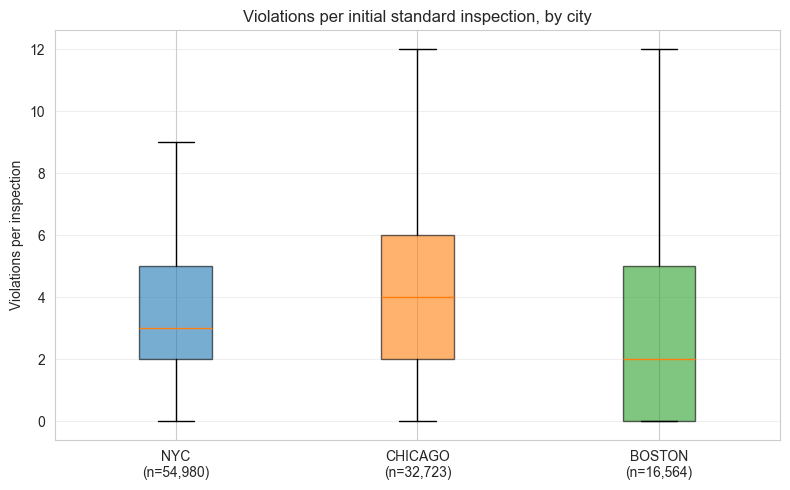

         count  mean  median   std
city                              
boston   16564 3.120   2.000 3.680
chicago  32723 4.450   4.000 3.940
nyc      54980 3.460   3.000 2.240


In [14]:
# Violations per inspection — box plot (standard, initial only)
vpi = con.execute("""
    SELECT city, violation_count
    FROM fact_inspections
    WHERE is_reinspection = FALSE
      AND is_standard_inspection = TRUE
      AND outcome_tier IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
data = [vpi.loc[vpi['city'] == c, 'violation_count'].values for c in CITY_ORDER]
labels = [f'{c.upper()}\n(n={len(d):,})' for c, d in zip(CITY_ORDER, data)]
bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
for patch, c in zip(bp['boxes'], CITY_ORDER):
    patch.set_facecolor(CITY_COLORS[c]); patch.set_alpha(0.6)
ax.set_ylabel('Violations per inspection')
ax.set_title('Violations per initial standard inspection, by city')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'violations_per_inspection.png'),
            dpi=150, bbox_inches='tight')
plt.show()

summary_vpi = vpi.groupby('city')['violation_count'].agg(
    ['count', 'mean', 'median', 'std']).round(2)
print(summary_vpi)

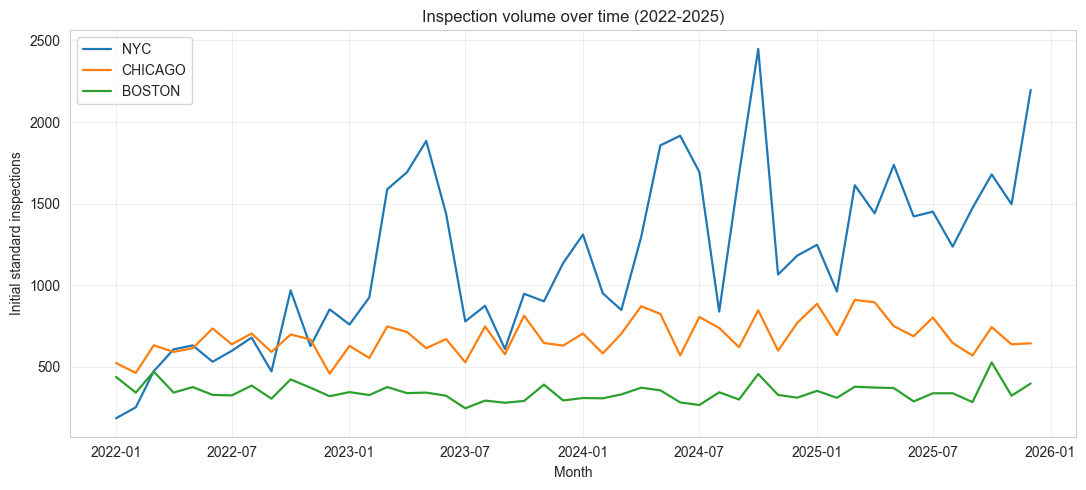

In [15]:
# Monthly inspection volume
monthly = con.execute("""
    SELECT city,
           DATE_TRUNC('month', inspection_date) AS month,
           COUNT(*) AS n
    FROM fact_inspections
    WHERE is_reinspection = FALSE
      AND is_standard_inspection = TRUE
    GROUP BY city, month
    ORDER BY city, month
""").df()
monthly['month'] = pd.to_datetime(monthly['month'])

fig, ax = plt.subplots(figsize=(11, 5))
for city in CITY_ORDER:
    sub = monthly[monthly['city'] == city]
    ax.plot(sub['month'], sub['n'], label=city.upper(),
            color=CITY_COLORS[city], linewidth=1.6)
ax.set_xlabel('Month')
ax.set_ylabel('Initial standard inspections')
ax.set_title('Inspection volume over time (2022-2025)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'monthly_inspection_volume.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Wrap-up

Outputs written to `outputs/`:

- `rq1_compliance_rates.csv`, `rq1_compliance_rates.png`
- `rq1_posthoc_pairs.csv`
- `rq2_top_categories_by_city.csv`, `rq2_taxonomy_heatmap.png`
- `rq2_universal_categories.csv`, `rq2_city_specific_categories.csv`
- `violations_per_inspection.png`, `monthly_inspection_volume.png`

These feed directly into the Results section of the report.

In [16]:
con.close()
print('Done.')

Done.
